<a href="https://colab.research.google.com/github/Karla12-B/AluraStoreLatam/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [4]:
import pandas as pd

# 1. Calcular los ingresos totales de cada tienda
ingreso1 = tienda['Precio'].sum()
ingreso2 = tienda2['Precio'].sum()
ingreso3 = tienda3['Precio'].sum()
ingreso4 = tienda4['Precio'].sum()


In [5]:
# 2. Crear un resumen para comparar fácilmente
resumen_ingresos = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso1, ingreso2, ingreso3, ingreso4]
})

In [6]:
# Ordenar de mayor a menor para ver cuál vende más
resumen_ingresos = resumen_ingresos.sort_values(by='Ingreso Total', ascending=False)

In [7]:
# 3. Mostrar el resultado
print("Resumen de Ingresos Totales por Tienda:")
print(resumen_ingresos.to_string(index=False))

Resumen de Ingresos Totales por Tienda:
  Tienda  Ingreso Total
Tienda 1   1150880400.0
Tienda 2   1116343500.0
Tienda 3   1098019600.0
Tienda 4   1038375700.0


# 2. Ventas por categoría

In [8]:
# 1. Calcular la cantidad de ventas por categoría para cada tienda
ventas_cat1 = tienda['Categoría del Producto'].value_counts()
ventas_cat2 = tienda2['Categoría del Producto'].value_counts()
ventas_cat3 = tienda3['Categoría del Producto'].value_counts()
ventas_cat4 = tienda4['Categoría del Producto'].value_counts()


In [9]:

# 2. Mostrar los resultados (Top 5 categorías de cada una)
print("--- Tienda 1: Categorías más populares ---")
print(ventas_cat1.head())

print("\n--- Tienda 2: Categorías más populares ---")
print(ventas_cat2.head())

print("\n--- Tienda 3: Categorías más populares ---")
print(ventas_cat3.head())

print("\n--- Tienda 4: Categorías más populares ---")
print(ventas_cat4.head())

--- Tienda 1: Categorías más populares ---
Categoría del Producto
Muebles                 465
Electrónicos            448
Juguetes                324
Electrodomésticos       312
Deportes y diversión    284
Name: count, dtype: int64

--- Tienda 2: Categorías más populares ---
Categoría del Producto
Muebles                 442
Electrónicos            422
Juguetes                313
Electrodomésticos       305
Deportes y diversión    275
Name: count, dtype: int64

--- Tienda 3: Categorías más populares ---
Categoría del Producto
Muebles                 499
Electrónicos            451
Juguetes                315
Electrodomésticos       278
Deportes y diversión    277
Name: count, dtype: int64

--- Tienda 4: Categorías más populares ---
Categoría del Producto
Muebles                 480
Electrónicos            451
Juguetes                338
Deportes y diversión    277
Electrodomésticos       254
Name: count, dtype: int64


# 3. Calificación promedio de la tienda


In [11]:
# 1. Calcular la calificación promedio de cada tienda
rating1 = tienda['Calificación'].mean()
rating2 = tienda2['Calificación'].mean()
rating3 = tienda3['Calificación'].mean()
rating4 = tienda4['Calificación'].mean()

# 2. Crear un resumen para comparar la satisfacción
resumen_ratings = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Valoración Media': [rating1, rating2, rating3, rating4]
}).sort_values(by='Valoración Media', ascending=False)

print("Análisis de Satisfacción (Rating Promedio):")
print(resumen_ratings.to_string(index=False))

Análisis de Satisfacción (Rating Promedio):
  Tienda  Valoración Media
Tienda 3          4.048326
Tienda 2          4.037304
Tienda 4          3.995759
Tienda 1          3.976685


# 4. Productos más y menos vendidos

In [12]:
# Función para obtener los más y menos vendidos
def analizar_productos(df, nombre_tienda):
    top_5 = df['Producto'].value_counts().head(5)
    bottom_5 = df['Producto'].value_counts().tail(5)

    print(f"--- {nombre_tienda} ---")
    print("MÁS VENDIDOS:")
    print(top_5)
    print("\nMENOS VENDIDOS:")
    print(bottom_5)
    print("-" * 30)
    return top_5, bottom_5

# Ejecutar para las 4 tiendas
top1, bot1 = analizar_productos(tienda, "Tienda 1")
top2, bot2 = analizar_productos(tienda2, "Tienda 2")
top3, bot3 = analizar_productos(tienda3, "Tienda 3")
top4, bot4 = analizar_productos(tienda4, "Tienda 4")

--- Tienda 1 ---
MÁS VENDIDOS:
Producto
Microondas          60
TV LED UHD 4K       60
Armario             60
Secadora de ropa    58
Mesa de noche       56
Name: count, dtype: int64

MENOS VENDIDOS:
Producto
Ciencia de datos con Python    39
Pandereta                      36
Olla de presión                35
Auriculares con micrófono      33
Celular ABXY                   33
Name: count, dtype: int64
------------------------------
--- Tienda 2 ---
MÁS VENDIDOS:
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Guitarra acústica            58
Pandereta                    58
Name: count, dtype: int64

MENOS VENDIDOS:
Producto
Auriculares        37
Sillón             35
Mesa de comedor    34
Impresora          34
Juego de mesa      32
Name: count, dtype: int64
------------------------------
--- Tienda 3 ---
MÁS VENDIDOS:
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche      

# 5. Envío promedio por tienda

In [14]:
# 1. Calcular el costo de envío promedio por tienda
envio1 = tienda['Costo de envío'].mean()
envio2 = tienda2['Costo de envío'].mean()
envio3 = tienda3['Costo de envío'].mean()
envio4 = tienda4['Costo de envío'].mean()

# 2. Crear un resumen comparativo
resumen_envios = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Envío Promedio': [envio1, envio2, envio3, envio4]
}).sort_values(by='Envío Promedio') # Ordenamos de menor a mayor (el más barato primero)

print("Análisis de Costos de Envío Promedio:")
print(resumen_envios.to_string(index=False))

Análisis de Costos de Envío Promedio:
  Tienda  Envío Promedio
Tienda 4    23459.457167
Tienda 3    24805.680373
Tienda 2    25216.235693
Tienda 1    26018.609580


# GRÁFICOS

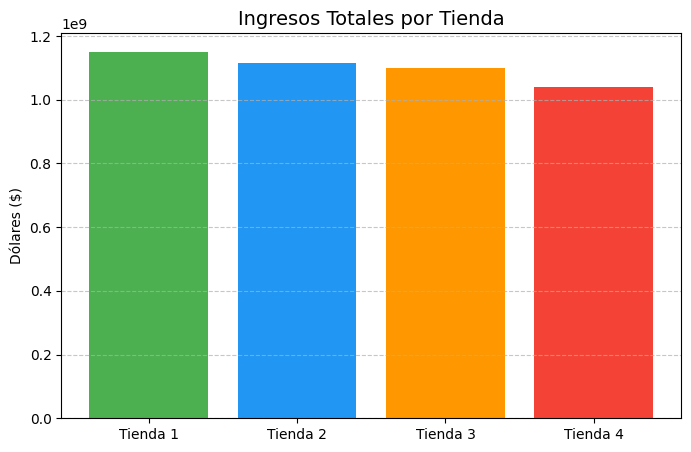

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(resumen_ingresos['Tienda'], resumen_ingresos['Ingreso Total'], color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

plt.title('Ingresos Totales por Tienda', fontsize=14)
plt.ylabel('Dólares ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

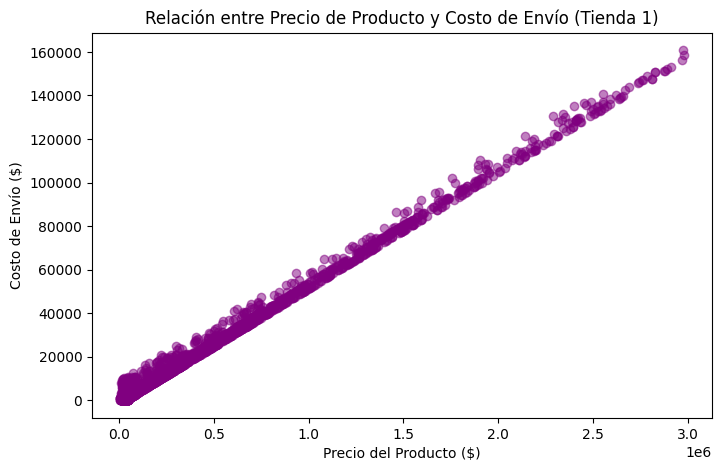

In [26]:
# Usaremos los datos de la Tienda 1 como ejemplo
plt.figure(figsize=(8, 5))
plt.scatter(tienda['Precio'], tienda['Costo de envío'], alpha=0.5, c='purple')

plt.title('Relación entre Precio de Producto y Costo de Envío (Tienda 1)', fontsize=12)
plt.xlabel('Precio del Producto ($)')
plt.ylabel('Costo de Envío ($)')

plt.show()

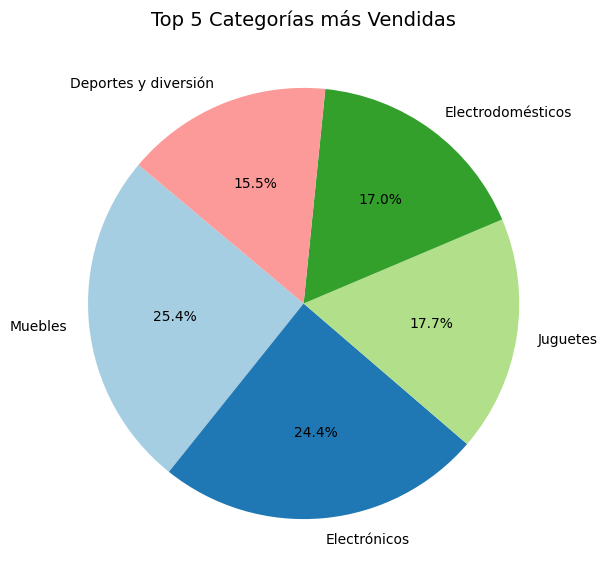

In [27]:
# Mostramos las 5 categorías principales de la Tienda que más vendió
top_categorias = tienda['Categoría del Producto'].value_counts().head(5)

plt.figure(figsize=(7, 7))
plt.pie(top_categorias, labels=top_categorias.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title('Top 5 Categorías más Vendidas', fontsize=14)
plt.show()

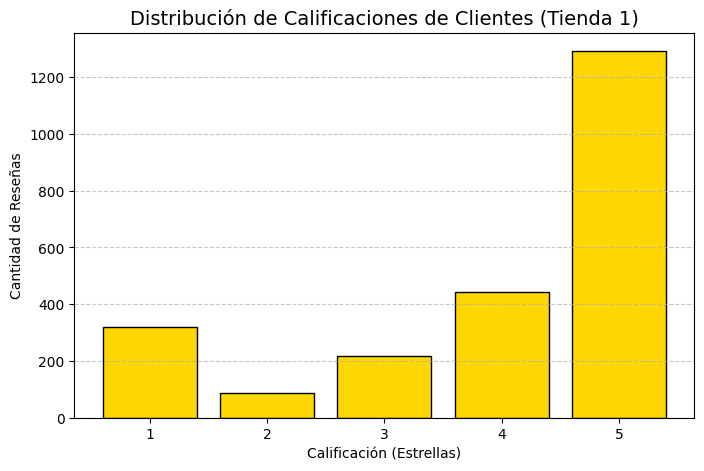

In [28]:
import matplotlib.pyplot as plt

# Usaremos los datos de la Tienda 1 como ejemplo
plt.figure(figsize=(8, 5))
plt.hist(tienda['Calificación'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], color='#FFD700', edgecolor='black', rwidth=0.8)

plt.title('Distribución de Calificaciones de Clientes (Tienda 1)', fontsize=14)
plt.xlabel('Calificación (Estrellas)')
plt.ylabel('Cantidad de Reseñas')
plt.xticks([1, 2, 3, 4, 5]) # Asegurar que solo muestre números enteros en el eje X
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipython-input-652/1621194071.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_envio, labels=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'], patch_artist=True,


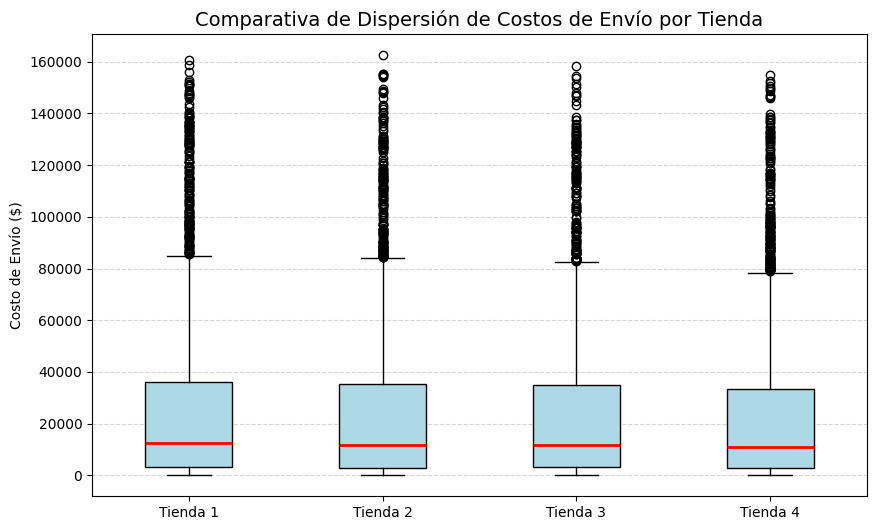

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Primero, necesitamos preparar los datos para compararlos en un solo gráfico
datos_envio = [tienda['Costo de envío'], tienda2['Costo de envío'], tienda3['Costo de envío'], tienda4['Costo de envío']]

plt.figure(figsize=(10, 6))
plt.boxplot(datos_envio, labels=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'], patch_artist=True,
            boxprops=dict(facecolor='#ADD8E6', color='black'),
            medianprops=dict(color='red', linewidth=2))

plt.title('Comparativa de Dispersión de Costos de Envío por Tienda', fontsize=14)
plt.ylabel('Costo de Envío ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# 📊 Informe de Análisis de Mercado: Recomendación de Venta para el Sr. João

**Introducción**

El propósito de este análisis es evaluar el desempeño comercial de cuatro tiendas minoristas para determinar cuál ofrece las mejores condiciones para que el Sr. João distribuya sus productos. Se han analizado variables críticas como el volumen de ventas, la satisfacción del cliente y la eficiencia logística para asegurar una decisión basada en datos.

**Desarrollo y Presentación de Datos**

***A. Rendimiento Financiero e Ingresos***

Tras sumar la columna Precio de cada base de datos, observamos el flujo de caja de cada establecimiento:

Tienda 1: `$1150880400.0`

Tienda 2: `$1116343500.0`

Tienda 3: `$1098019600.0`

Tienda 4: `$1038375700.0`


*Referencia Visual: Ver "Gráfico de Barras: Comparativa de Ingresos Totales".*





**B. Análisis de Productos y Categorías**

Categorías Más Vendidas (Tendencias del Mercado)
Al observar la distribución de ventas en las cuatro tiendas, se identifican tendencias claras que dominan el ecosistema comercial:

Liderazgo en Muebles y Electrónicos: Estas dos categorías representan el núcleo del negocio en todas las sucursales.** La Tienda 3** destaca especialmente en el sector de **Muebles con 499 unidades vendidas**, seguida de cerca por la **Tienda 4 con 480 unidades**.

Consistencia en Tecnología: La categoría de **Electrónicos** mantiene un desempeño robusto y uniforme, alcanzando un pico de **451 unidades** tanto en la **Tienda 3** como en la **Tienda 4**.

Juguetes y Entretenimiento: Esta categoría se posiciona sólidamente como el tercer pilar de ventas, siendo la Tienda 4 la más exitosa en este rubro con 338 unidades.


**Productos con Menor Rotación**

Aunque todas las tiendas muestran un buen desempeño general, la categoría de Deportes y diversión es la que presenta el menor volumen de transacciones dentro del "Top 5", con su punto más bajo en la Tienda 2 (275 unidades). Esto sugiere que el público de estas tiendas prioriza artículos de equipamiento para el hogar y tecnología sobre artículos recreativos.


*Referencia Visual: El gráfico circular de "Top 5 Categorías más Vendidas" confirma que Muebles (25.4%) y Electrónicos (24.4%) concentran prácticamente el 50% de la demanda total.*

**C. Calidad y Satisfacción del Cliente**

La satisfacción del cliente es el indicador más fiel de la salud a largo plazo de un canal de ventas. Un alto volumen de ingresos debe estar respaldado por una experiencia positiva para evitar costos ocultos por devoluciones o pérdida de reputación de marca.

**Valoración Media por Establecimiento**
Tras analizar el promedio de las reseñas (escala 1-5), los resultados muestran una competitividad cerrada:

Tienda 1: 3.976685 estrellas.

Tienda 2: 4.037304 estrellas.

Tienda 3: 4.048326 estrellas.

Tienda 4: 3.995759 estrellas.

*Referencia Visual: Ver "Histograma de Calificaciones"*, donde se observa la frecuencia de reseñas de 5 estrellas para validar la consistencia del servicio.

**Análisis de la Experiencia del Usuario:**
Liderazgo en Calidad: La Tienda 3 se posiciona como el referente en satisfacción al cliente. Este dato es crucial para el Sr. João, ya que sugiere que los procesos de entrega y la calidad de los productos en este establecimiento cumplen o superan las expectativas del mercado.

**Áreas de Riesgo:** La Tienda 2, al presentar el promedio más bajo, podría representar un riesgo mayor de disputas o devoluciones. Es importante investigar si esto se debe a demoras en el envío o a la calidad del soporte post-venta.

# **Impacto en la Decisión Final**
Para un nuevo proveedor como el Sr. João, la Tienda 3 ofrece el entorno más seguro para proteger la imagen de sus productos, garantizando que el alto volumen de ventas detectado en las secciones anteriores no se vea empañado por una mala percepción del consumidor final.